In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the transaction data
df = pd.read_csv('../data/raw/data.csv')
print("Shape:", df.shape)
df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [3]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


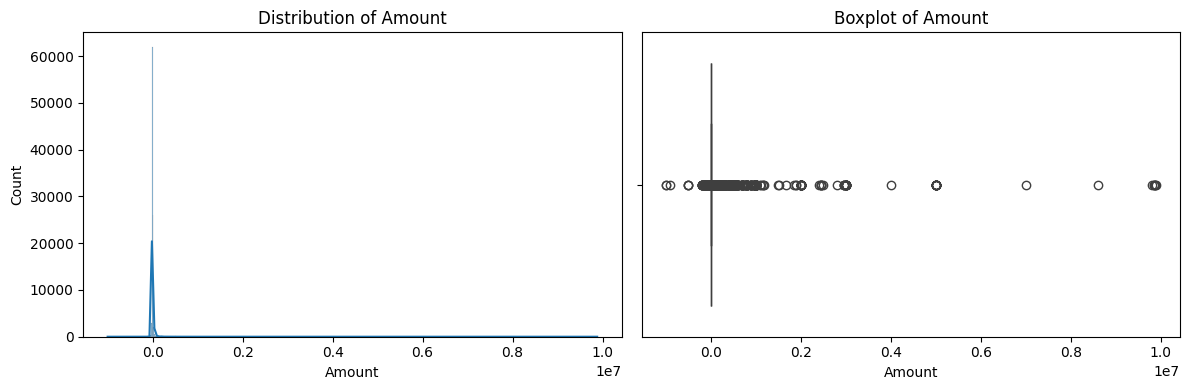

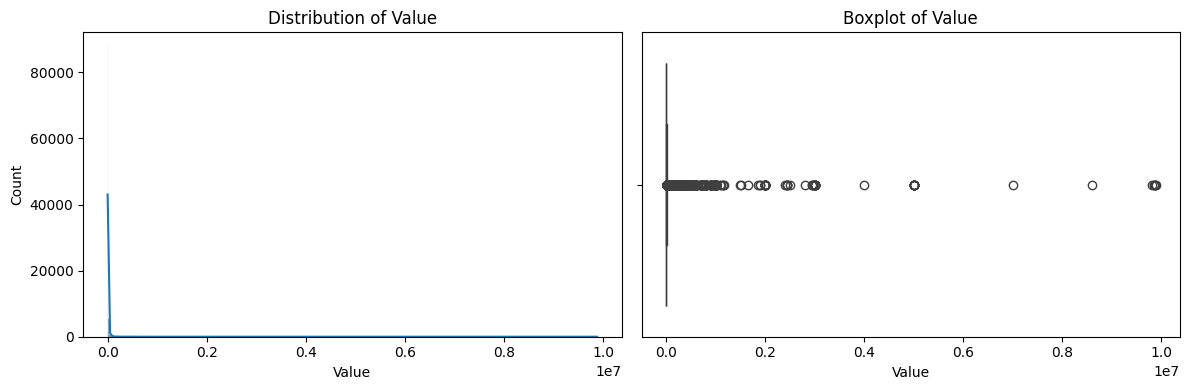

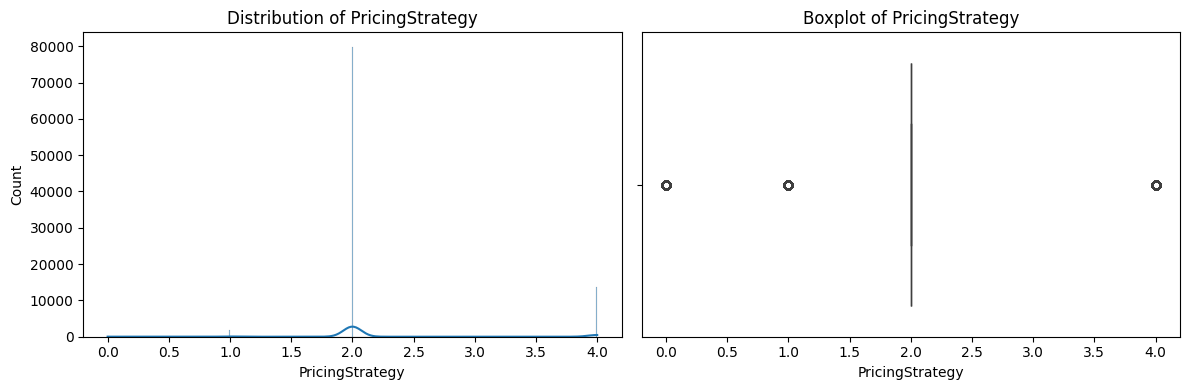

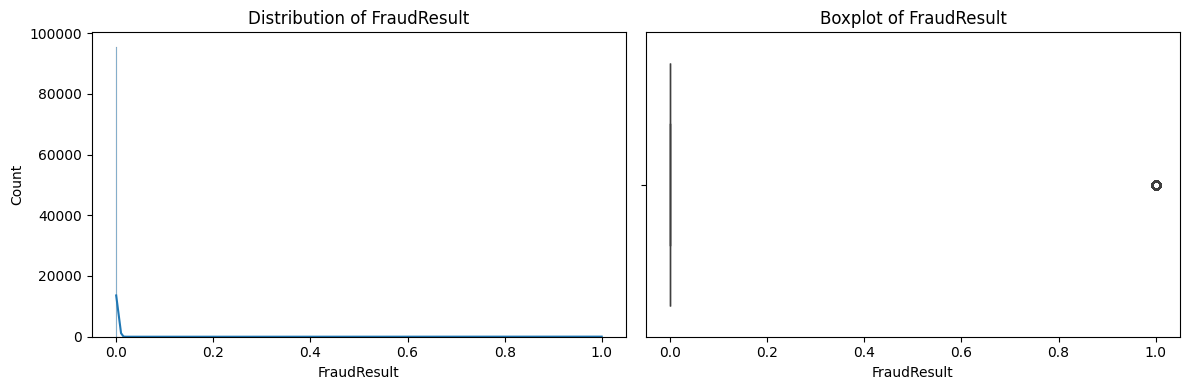

In [4]:
# Identify numerical columns (exclude ID columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CountryCode', 'ProviderId', 'ProductId']
num_cols = [col for col in num_cols if col not in exclude]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

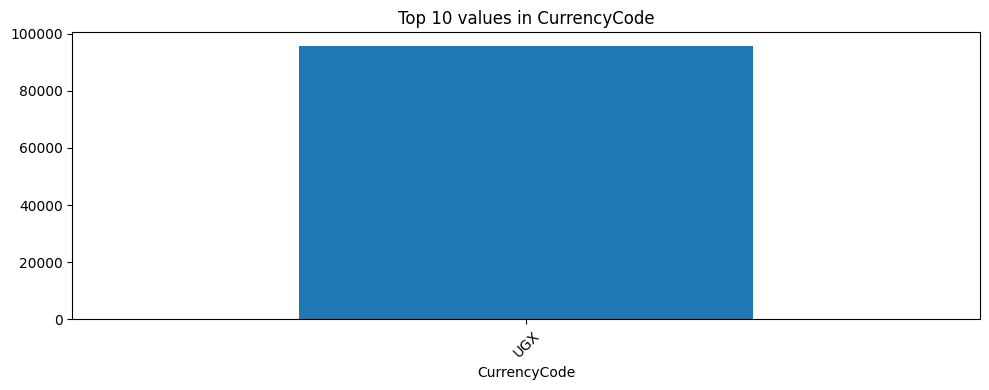

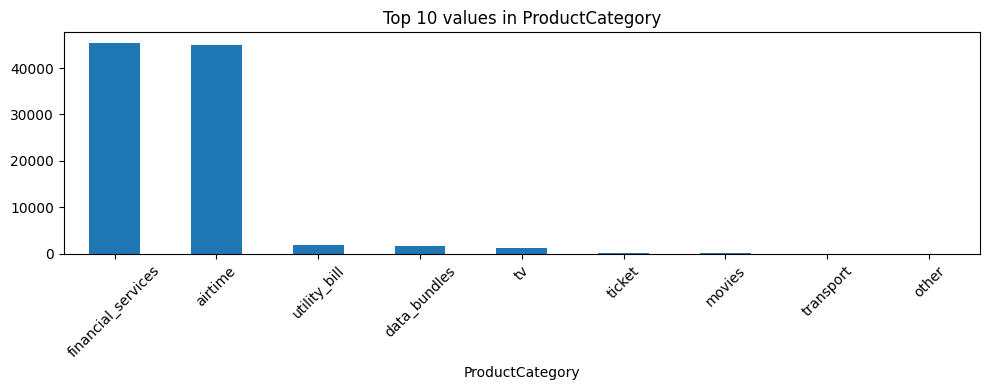

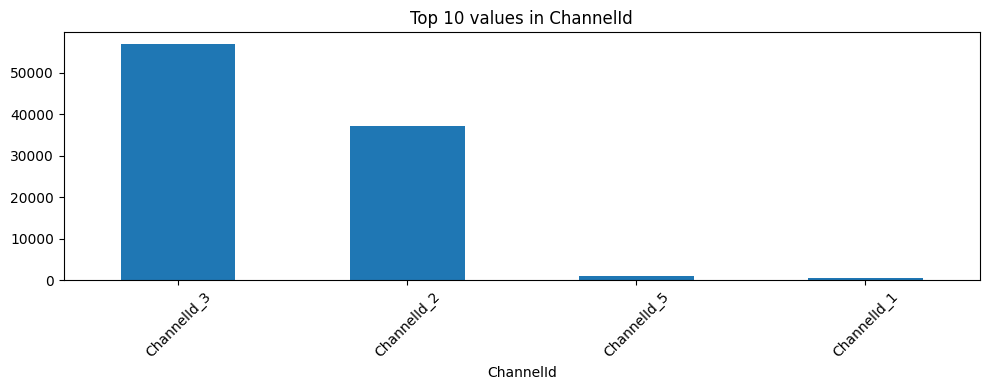

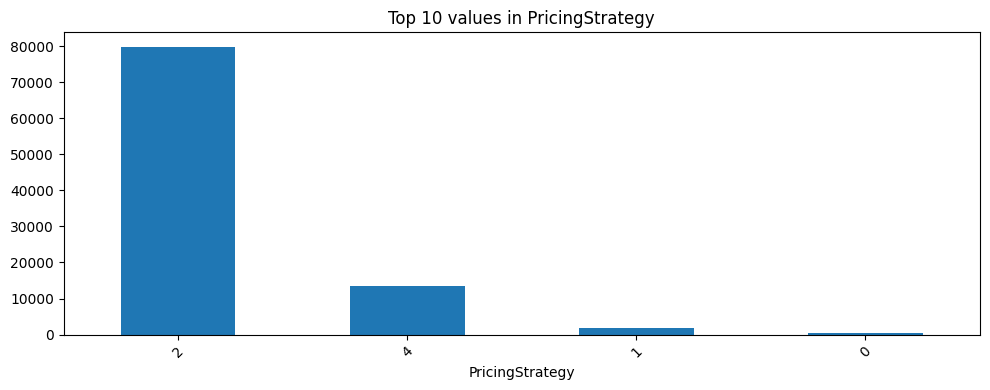

In [5]:
cat_cols = ['CurrencyCode', 'ProductCategory', 'ChannelId', 'PricingStrategy']
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        df[col].value_counts().head(10).plot(kind='bar')
        plt.title(f'Top 10 values in {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

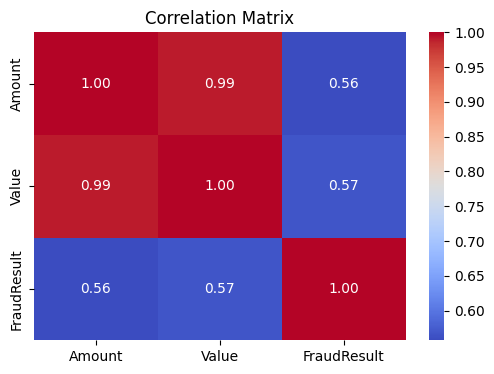

In [6]:
# Only numerical columns that make sense
corr_cols = ['Amount', 'Value']  # Value is absolute of Amount, highly correlated
if 'FraudResult' in df.columns:
    corr_cols.append('FraudResult')
corr = df[corr_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

Empty DataFrame
Columns: [Missing, Percentage]
Index: []


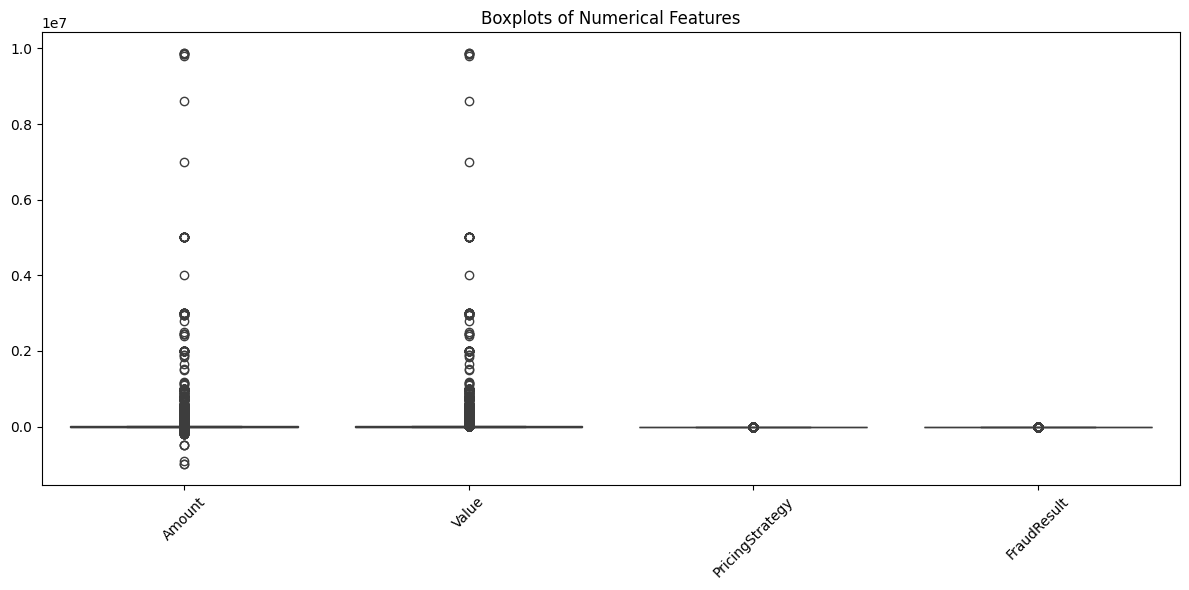

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

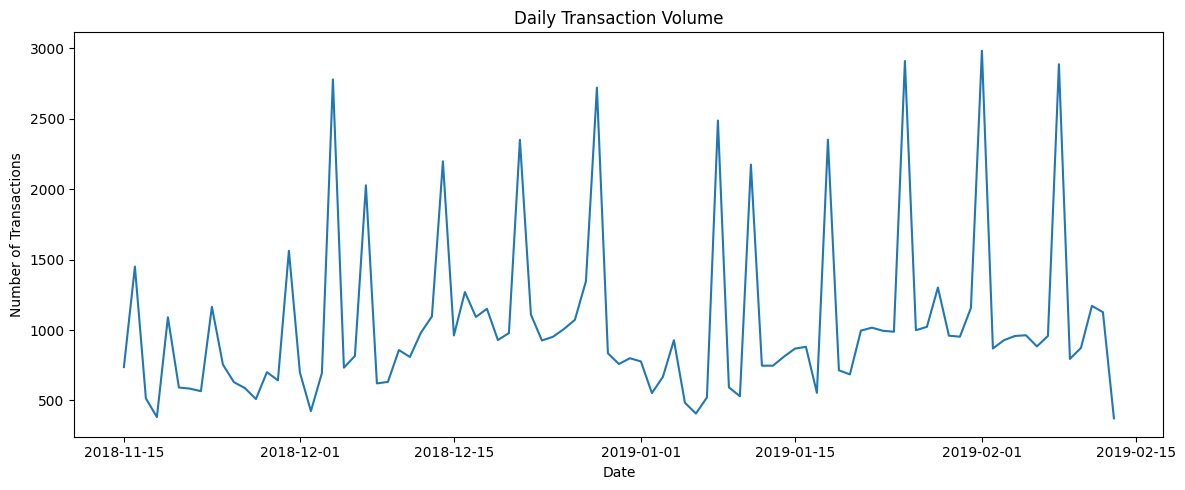

In [9]:
if 'TransactionStartTime' in df.columns:
    df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
    df['Date'] = df['TransactionStartTime'].dt.date
    daily_counts = df.groupby('Date').size()
    plt.figure(figsize=(12,5))
    daily_counts.plot()
    plt.title('Daily Transaction Volume')
    plt.xlabel('Date')
    plt.ylabel('Number of Transactions')
    plt.tight_layout()
    plt.show()

## Top 5 Insights from EDA

1. **No missing values** – the dataset is complete.
2. **Highly imbalanced target:** Only ~0.2% of transactions are fraudulent (`FraudResult=1`). This will affect model evaluation.
3. **Extreme outliers** in `Amount` and `Value` (max ~9.88 million). Consider capping or using robust scaling.
4. **Dominant product categories:** `airtime`, `financial_services`, `utility_bill` – these may drive different risk profiles.
5. **Transaction volume spikes** on certain dates – could be due to promotions or seasonality.